In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares, root

In [13]:
## Disk parameters
alpha = 1e-3
M_disk = 0.1 # M_sun
T_0 = 18.9737 # K
a_c = 50 # AU
d2g = 0.01
D = 0.2
b_tilde = 10
mu = 2.33

## Star parameters
M_star = 1.0 # M_sun

## Planetesimal parameters
rho_pltsml = 2.0 # g/cm^3
R_pltsml = 100 # km

## Embryo core parameters
rho_core = 2.0 # g/cm^3

## Constants
G = 6.67e-8 # cm^3/g/s^2
k_B = 1.38e-16 # erg/K
m_H = 1.67e-24 # g
M_earth = 5.97e27 # g
M_sun = 1.99e33 # g
AU = 1.496e13 # cm
year = 3.156e7 # s
sigma_H2 = 2.61e-15 # cm^2

In [14]:
## Disk structure helper functions

def Sigma_0(M_disk, a_c):
    """Calculates the normalization constant for the surface density profile."""
    return M_disk * M_sun / (2 * np.pi * (a_c * AU) ** 2)

def Sigma_g(a):
    """Calculates the gas surface density of the disk in g/cm^2."""
    return Sigma_0(M_disk, a_c) * (a / a_c) ** (-1) * np.exp(-a / a_c)

def Sigma_s(a):
    """Calculates the solid surface density of the disk in g/cm^2."""
    return d2g * Sigma_g(a)

def T(a):
    """Calculates the temperature of the disk in K."""
    return T_0 * (a / a_c) ** (-0.5)

def Reynolds(e2, i2, a):
    """Calculates the Reynolds number."""
    nu_mol = mfp_H2(a) * c_s(a) / 3
    return v_rel(e2, i2, a) * (R_pltsml * 1e5) / nu_mol

def c_s(a):
    """Calculates the sound speed of the disk in cm/s."""
    return np.sqrt(k_B * T(a) / (mu * m_H))

def H(a):
    """Calculates the scale height of the disk in AU."""
    return c_s(a) / Omega_K(a) / AU

def mfp_H2(a):
    """Calculates the mean free path of H2 in cm."""
    n_H2 = rho_mid(a) / (mu * m_H)
    return (n_H2 * sigma_H2) ** (-1)

def rho_mid(a):
    """Calculates the midplane gas density of the disk in g/cm^3."""
    return Sigma_g(a) / (np.sqrt(2 * np.pi) * H(a) * AU)

## Embryo and planetesimal helper functions

def v_rel(e2, i2, a):
    """Calculates the relative velocity between planetesimals and the embryo in cm/s (Fortier et al. 2012)."""
    return Omega_K(a) * a * AU * np.sqrt(5/8 * e2 + 1/2 * i2)


def M_pltsml(R_pltsml):
    """Calculates the mass of a planetesimal assuming constant density in Earth masses."""
    return (4/3) * np.pi * (R_pltsml * 1e5) ** 3 * rho_pltsml / M_earth

def Omega_K(a):
    """Calculates the Keplerian angular velocity in rad/s."""
    return np.sqrt(G * M_star * M_sun / (a * AU) ** 3)

def R_core(M_core):
    """Calculates the core radius assuming a constant density in km."""
    return (3 * M_core * M_earth / (4 * np.pi * rho_core)) ** (1/3) / 1e5

def R_H(M_core, a_core):
    """Calculates the Hill radius in AU."""
    return a_core * (M_core * M_earth / (3 * M_star * M_sun)) ** (1/3)

## Eccentricity and inclination helper functions

def f_j(a_0, a_j, M_j):
    """Distance modulation function for embryo j (Kaufmann & Alibert 2023)."""
    return 1 / (1 + abs(a_0 - a_j) / (5 * R_H(M_j, a_j)))

def P_VS(e_tilde, i_tilde):
    """Stirring function for eccentricity (Kaufmann & Alibert 2023)."""
    Lambda = 1/12 * (e_tilde ** 2 + i_tilde ** 2) * i_tilde
    beta = i_tilde / e_tilde
    return (73 * e_tilde ** 2) / (10 * Lambda ** 2) * np.log(1 + 10 * Lambda ** 2 / (e_tilde ** 2)) + (72 * I_PVS(beta)) / (np.pi * e_tilde * i_tilde) * np.log(1 + Lambda ** 2)

def Q_VS(e_tilde, i_tilde):
    """Stirring function for inclination (Kaufmann & Alibert 2023)."""
    Lambda = 1/12 * (e_tilde ** 2 + i_tilde ** 2) * i_tilde
    beta = i_tilde / e_tilde
    return (4 * i_tilde ** 2 + 0.2 * i_tilde * e_tilde ** 3) / (10 * Lambda ** 2 * e_tilde) * np.log(1 + 10 * Lambda ** 2 * e_tilde) + (72 * I_QVS(beta)) / (np.pi * e_tilde * i_tilde) * np.log(1 + Lambda ** 2)

def I_PVS(beta):
    """Numerical elliptic integral approximation (Kaufmann & Alibert 2023)."""
    return (beta - 0.36251) / (0.061547 + 0.16112 * beta + 0.054473 * beta ** 2)

def I_QVS(beta):
    """Numerical elliptic integral approximation (Kaufmann & Alibert 2023)."""
    return (0.71946 - beta) / (0.21239 + 0.49764 * beta + 0.14369 * beta ** 2)

def t_stop(e2, i2, a_0):
    """Planetesimal gas drag stopping time in s (Kaufmann & Alibert 2023)."""

    if R_pltsml * 1e5 < 1.5 * mfp_H2(a_0):
        return rho_pltsml * (R_pltsml * 1e5) / (rho_mid(a_0) * c_s(a_0))
    
    else:
        if Reynolds(e2, i2, a_0) < 27:
            return 2 * rho_pltsml * (R_pltsml * 1e5) ** 2 / (3 * rho_mid(a_0) * mfp_H2(a_0) * c_s(a_0))
        
        else:
            return 6 * rho_pltsml * (R_pltsml * 1e5) / (rho_mid(a_0) * v_rel(e2, i2, a_0))

def e_tilde_embryo(e2, M_core):
    """Calculates the embryo reduced eccentricity."""
    return np.sqrt(np.maximum(e2, 0)) / (M_core * M_earth / (3 * M_star * M_sun)) ** (1/3)

def i_tilde_embryo(i2, M_core):
    """Calculates the embryo reduced inclination."""
    return np.sqrt(np.maximum(i2, 0)) / (M_core * M_earth / (3 * M_star * M_sun)) ** (1/3)

def e_tilde_pltsml(e2):
    """Calculates the planetesimal reduced eccentricity."""
    return 2 * np.sqrt(np.maximum(e2, 0)) / (2 * M_pltsml(R_pltsml) * M_earth / (3 * M_star * M_sun)) ** (1/3)

def i_tilde_pltsml(i2):
    """Calculates the planetesimal reduced inclination."""
    return 2 * np.sqrt(np.maximum(i2, 0)) / (2 * M_pltsml(R_pltsml) * M_earth / (3 * M_star * M_sun)) ** (1/3)

In [15]:
## Wrapper function for scipy.optimize.least_squares() or scipy.optimize.root()

def equilibrium(x, a_0, a_cores, M_cores, drag = True, VS_embryo = True, VS_pltsml = True, DF = True):
    """Returns [de2/dt, di2/dt] for a trial [e2, i2]."""

    e2, i2 = x

    return np.array([de2_dt(e2, i2, a_0, a_cores, M_cores, drag, VS_embryo, VS_pltsml, DF) * 1e6 * year, di2_dt(e2, i2, a_0, a_cores, M_cores, drag, VS_embryo, VS_pltsml, DF) * 1e6 * year])

## ODEs

def de2_dt(e2, i2, a_0, a_cores, M_cores, drag = True, VS_embryo = True, VS_pltsml = True, DF = True):
    """Evolution equation for local planetesimal eccentricity squared (Kaufmann & Alibert 2023)."""
    e2_dot = 0

    if drag:
        e2_dot += de2_dt_drag(e2, i2, a_0)

    if VS_embryo:
        e2_dot += de2_dt_VS_embryo(e2, i2, a_0, a_cores, M_cores)

    if VS_pltsml:
        e2_dot += de2_dt_VS_pltsml(e2, i2, a_0)

    if DF:
        e2_dot += de2_dt_DF(e2, i2, a_0)
    
    return e2_dot

def di2_dt(e2, i2, a_0, a_cores, M_cores, drag = True, VS_embryo = True, VS_pltsml = True, DF = True):
    """Evolution equation for local planetesimal inclination squared (Kaufmann & Alibert 2023)."""
    i2_dot = 0

    if drag:
        i2_dot += di2_dt_drag(e2, i2, a_0)

    if VS_embryo:
        i2_dot += di2_dt_VS_embryo(e2, i2, a_0, a_cores, M_cores)

    if VS_pltsml:
        i2_dot += di2_dt_VS_pltsml(e2, i2, a_0)

    if DF:
        i2_dot += di2_dt_DF(e2, i2, a_0)
    
    return i2_dot

## Gas drag terms

def de2_dt_drag(e2, i2, a_0):
    """Gas drag term in eccentricity evolution (Kaufmann & Alibert 2023)."""

    if R_pltsml * 1e5 < 1.5 * mfp_H2(a_0):
        return -1 * e2 * c_s(a_0) * rho_mid(a_0) / (rho_pltsml * R_pltsml * 1e5)
    
    else:
        if Reynolds(e2, i2, a_0) < 27:
            return -3/2 * e2 * mfp_H2(a_0) * c_s(a_0) * rho_mid(a_0) / (rho_pltsml * (R_pltsml * 1e5) ** 2)
        
        else:
            return -2 * e2 * v_rel(e2, i2, a_0) * rho_mid(a_0) / (6 * rho_pltsml * R_pltsml * 1e5)

def di2_dt_drag(e2, i2, a_0):
    """Gas drag term in inclination evolution (Kaufmann & Alibert 2023)."""

    if R_pltsml * 1e5 < 1.5 * mfp_H2(a_0):
        return -1/2 * i2 * c_s(a_0) * rho_mid(a_0) / (rho_pltsml * R_pltsml * 1e5)
    
    else:
        if Reynolds(e2, i2, a_0) < 27:
            return -3/4 * i2 * mfp_H2(a_0) * c_s(a_0) * rho_mid(a_0) / (rho_pltsml * (R_pltsml * 1e5) ** 2)
        
        else:
            return -1 * i2 * v_rel(e2, i2, a_0) * rho_mid(a_0) / (6 * rho_pltsml * R_pltsml * 1e5)
        
## Planetesimal viscous stirring terms

def de2_dt_VS_pltsml(e2, i2, a_0):
    """Viscous stirring due to planetesimal-planetesimal interactions (Fortier et al 2012)."""
    e_tilde = e_tilde_pltsml(e2)
    i_tilde = i_tilde_pltsml(i2)
    return 1/6 * np.sqrt(G * a_0 * AU / (M_star * M_sun)) * Sigma_s(a_0) * (2 * M_pltsml(R_pltsml) * M_earth / (3 * M_star * M_sun)) ** (1/3) * P_VS(e_tilde, i_tilde)

def di2_dt_VS_pltsml(e2, i2, a_0):
    """Viscous stirring due to planetesimal-planetesimal interactions (Fortier et al 2012)."""
    e_tilde = e_tilde_pltsml(e2)
    i_tilde = i_tilde_pltsml(i2)
    return 1/6 * np.sqrt(G * a_0 * AU / (M_star * M_sun)) * Sigma_s(a_0) * (2 * M_pltsml(R_pltsml) * M_earth / (3 * M_star * M_sun)) ** (1/3) * Q_VS(e_tilde, i_tilde)

## Embryo viscous stirring terms

def de2_dt_VS_embryo(e2, i2, a_0, a_cores, M_cores):
    """Viscous stirring due to all embryos acting on planetesimals local to a_0 (Kaufmann & Alibert 2023)."""
    e2_VS = 0
    for a_j, M_j in zip(a_cores, M_cores):
        e_tilde = e_tilde_embryo(e2, M_j)
        i_tilde = i_tilde_embryo(i2, M_j)
        e2_VS += f_j(a_0, a_j, M_j) * Omega_K(a_0) * M_j * M_earth / (6 * np.pi * b_tilde * M_star * M_sun) * P_VS(e_tilde, i_tilde)
    return e2_VS

def di2_dt_VS_embryo(e2, i2, a_0, a_cores, M_cores):
    """Viscous stirring due to all embryos acting on planetesimals local to a_0 (Kaufmann & Alibert 2023)."""
    i2_VS = 0
    for a_j, M_j in zip(a_cores, M_cores):
        e_tilde = e_tilde_embryo(e2, M_j)
        i_tilde = i_tilde_embryo(i2, M_j)
        i2_VS += f_j(a_0, a_j, M_j) * Omega_K(a_0) * M_j * M_earth / (6 * np.pi * b_tilde * M_star * M_sun) * Q_VS(e_tilde, i_tilde)
    return i2_VS

## Density fluctuations stirring terms

def de2_dt_DF(e2, i2, a_0):
    """Density fluctuation term in eccentricity evolution (Kaufmann & Alibert 2023)."""
    return 400 * alpha * (H(a_0) * AU * a_0 * AU * Sigma_g(a_0) / (M_star * M_sun)) ** 2 * Omega_K(a_0) + (4 * alpha / (3 * Omega_K(a_0) * t_stop(e2, i2, a_0) ** 2)) * (c_s(a_0) / (Omega_K(a_0) * a_0 * AU)) ** 2

def di2_dt_DF(e2, i2, a_0):
    """Density fluctuation term in inclination evolution (Kaufmann & Alibert 2023)."""
    return 4 * alpha * (H(a_0) * AU * a_0 * AU * Sigma_g(a_0) / (M_star * M_sun)) ** 2 * Omega_K(a_0) + (2 * alpha / (3 * Omega_K(a_0) * t_stop(e2, i2, a_0) ** 2)) * (c_s(a_0) / (Omega_K(a_0) * a_0 * AU)) ** 2

In [16]:
## Equilibrium eccentricity

def e_eq_VS_embryo(a_0, M_core):
    """Calculates the equilibrium eccentricity by balancing embryo stirring with gas drag (Fortier et al 2012)"""
    return 1.7 * (M_pltsml(R_pltsml) * M_earth) ** (1/15) * (M_core * M_earth) ** (1/3) * rho_pltsml ** (2/15) / (b_tilde ** (1/5) * D ** (1/5) * rho_mid(a_0) ** (1/5) * (M_star * M_sun) ** (1/3) * (a_0 * AU) ** (1/5))

def e_eq_VS_pltsml(a_0):
    """Calculates the equilibrium eccentrictiy by balancing planetesimal self stirring with gas drag (Fortier et al 2012)"""
    return 2.31 * (M_pltsml(R_pltsml) * M_earth) ** (4/15) * (a_0 * AU) ** (1/5) * rho_pltsml ** (2/15) * Sigma_s(a_0) ** (1/5) / (D ** (1/5) * rho_mid(a_0) ** (1/5) * (M_star * M_sun) ** (2/5))

## Equilibrium inclination

def i_eq(e_eq):
    """Calculates the equilibrium inclination (Fortier et al 2012)"""
    return 1/2 * e_eq

In [17]:
## Find equilibrium solution using scipy.optimize.least_squares()

drag = True
VS_embryo = True
VS_pltsml = True
DF = True

a_0 = 6 # AU
a_cores = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 10.0, 15.0, 20.0, 25.0, 30.0]) # AU
n_cores = len(a_cores)
M_cores = np.full(n_cores, M_pltsml(R_pltsml)) # Earth masses
e_0 = 0.02
i_0 = e_0 / 2

sol = least_squares(equilibrium, x0 = np.array([e_0 ** 2, i_0 ** 2]), args = (a_0, a_cores, M_cores, drag, VS_embryo, VS_pltsml, DF), bounds = ([0, 0], [np.inf, np.inf]), ftol = 1e-14, xtol = 1e-14, gtol = 1e-14)

e2_eq_num, i2_eq_num = sol.x

e_eq_num = np.sqrt(e2_eq_num)
i_eq_num = np.sqrt(i2_eq_num)

print(f'Success: {sol.success}')
print(f'Message: {sol.message}')
print()
print(f'e_eq = {e_eq_num}')
print(f'i_eq = {i_eq_num}')
print()
print(f'Residuals: {sol.fun}')
print(f'Cost: {sol.cost}')

Success: True
Message: `gtol` termination condition is satisfied.

e_eq = 0.0289471585875855
i_eq = 0.005616326981813954

Residuals: [-3.02886371e-12 -2.95289620e-12]
Cost: 8.946805676310072e-24


In [18]:
## Find equilibrium solution using scipy.optimize.root()

drag = True
VS_embryo = True
VS_pltsml = True
DF = True

a_0 = 1 # AU
a_cores = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 10.0, 15.0, 20.0, 25.0, 30.0]) # AU
n_cores = len(a_cores)
M_cores = np.full(n_cores, M_pltsml(R_pltsml)) # Earth masses
e_0 = 0.1
i_0 = e_0 / 2

sol = root(equilibrium, x0 = np.array([e_0 ** 2, i_0 ** 2]), args = (a_0, a_cores, M_cores, drag, VS_embryo, VS_pltsml, DF), tol = 1e-12)

e2_eq_num, i2_eq_num = sol.x

e_eq_num = np.sqrt(e2_eq_num)
i_eq_num = np.sqrt(i2_eq_num)

print(f'Success: {sol.success}')
print(f'Message: {sol.message}')
print()
print(f'e_eq = {e_eq_num}')
print(f'i_eq = {i_eq_num}')
print()
print(f'Residuals: {sol.fun}')

Success: True
Message: The solution converged.

e_eq = 0.0039030641539078313
i_eq = 0.002137767164042902

Residuals: [-9.72517585e-20  1.36760285e-20]


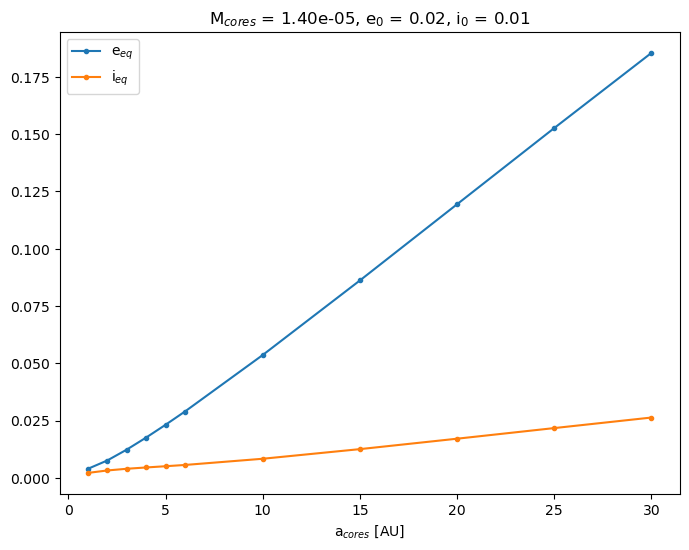

e_eq = [0.003915254060615388, 0.007564636080678143, 0.01229565755296402, 0.017561302971385636, 0.023142287041562883, 0.028946678019242365, 0.05358849219403995, 0.08612652398947196, 0.1193809957125783, 0.15262664173158222, 0.1854150157044841]
i_eq = [0.0021463608238145434, 0.0032143477765886274, 0.003952640719989076, 0.004527739213906267, 0.005064583243078464, 0.005620840147218439, 0.008327205481916304, 0.012528302759468332, 0.01707997039846399, 0.021712875128496244, 0.026313562478394788]


In [19]:
## All terms

drag = True
VS_embryo = True
VS_pltsml = True
DF = True

a_cores = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 10.0, 15.0, 20.0, 25.0, 30.0]) # AU
n_cores = len(a_cores)
M_cores = np.full(n_cores, M_pltsml(R_pltsml) * 10) # Earth masses
e_0 = 0.02
i_0 = e_0 / 2

e_eq_num = []
i_eq_num = []

e_eq_err = []
i_eq_err = []

for a_0 in a_cores:
    sol = least_squares(equilibrium, x0 = np.array([e_0 ** 2, i_0 ** 2]), args = (a_0, a_cores, M_cores, drag, VS_embryo, VS_pltsml, DF), bounds = ([0, 0], [np.inf, np.inf]), ftol = 1e-14, xtol = 1e-14, gtol = 1e-14)

    e2_eq_num, i2_eq_num = sol.x

    e_eq_num.append(float(np.sqrt(e2_eq_num)))
    i_eq_num.append(float(np.sqrt(i2_eq_num)))

    e_eq_err.append(abs(sol.fun[0]))
    i_eq_err.append(abs(sol.fun[1]))

    if sol.success != True:
        print(f'{a_0} AU Message: {sol.message}')

fig, ax = plt.subplots(figsize = (8, 6))

ax.plot(a_cores, e_eq_num, marker = '.', color = 'tab:blue', label = r'e$_{eq}$')
ax.plot(a_cores, i_eq_num, marker = '.', color = 'tab:orange', label = r'i$_{eq}$')

plt.xlabel(r'a$_{cores}$ [AU]')
plt.title(fr'M$_{{cores}}$ = {M_cores[0]:.2e}, e$_{{0}}$ = {e_0}, i$_{{0}}$ = {i_0}')
ax.legend()

plt.show()

print(f'e_eq = {e_eq_num}')
print(f'i_eq = {i_eq_num}')

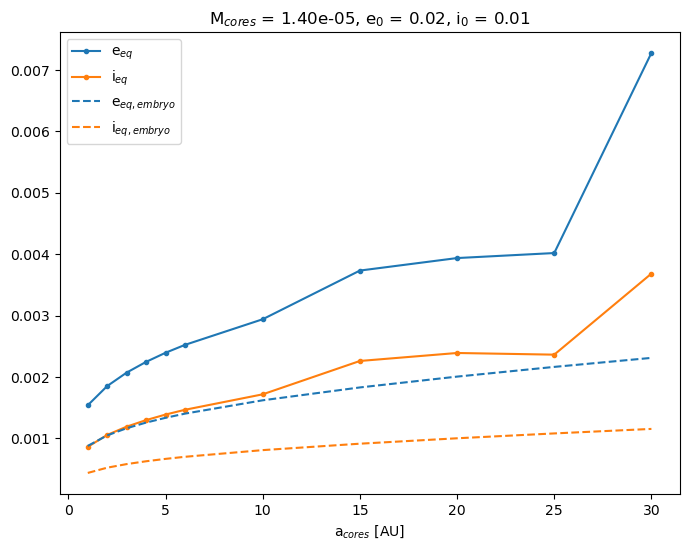

e_eq = [0.0015403279458821703, 0.0018528410523374434, 0.002071317187546525, 0.002245934211591346, 0.002393994527787289, 0.0025223997396197724, 0.0029393095734770672, 0.0037311120174913087, 0.003934586036469047, 0.0040161474425416, 0.007271340058426672]
i_eq = [0.0008637727476822111, 0.0010580599057159116, 0.0011922173419503398, 0.001298767497542863, 0.0013887494289343352, 0.0014665645063639654, 0.001718131956985317, 0.0022606403789217867, 0.002390532591181491, 0.0023633219334813, 0.003681703093697722]


In [20]:
## drag and VS_embryo

drag = True
VS_embryo = True
VS_pltsml = False
DF = False

a_cores = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 10.0, 15.0, 20.0, 25.0, 30.0]) # AU
n_cores = len(a_cores)
M_cores = np.full(n_cores, M_pltsml(R_pltsml) * 10) # Earth masses
e_0 = 0.02
i_0 = e_0 / 2

e_eq_num = []
i_eq_num = []

e_eq_err = []
i_eq_err = []

for a_0 in a_cores:
    sol = least_squares(equilibrium, x0 = np.array([e_0 ** 2, i_0 ** 2]), args = (a_0, a_cores, M_cores, drag, VS_embryo, VS_pltsml, DF), bounds = ([0, 0], [np.inf, np.inf]), ftol = 1e-14, xtol = 1e-14, gtol = 1e-14)

    e2_eq_num, i2_eq_num = sol.x

    e_eq_num.append(float(np.sqrt(e2_eq_num)))
    i_eq_num.append(float(np.sqrt(i2_eq_num)))

    e_eq_err.append(abs(sol.fun[0]))
    i_eq_err.append(abs(sol.fun[1]))

    if sol.success != True:
        print(f'{a_0} AU Message: {sol.message}')

fig, ax = plt.subplots(figsize = (8, 6))

ax.plot(a_cores, e_eq_num, marker = '.', color = 'tab:blue', label = r'e$_{eq}$')
ax.plot(a_cores, i_eq_num, marker = '.', color = 'tab:orange', label = r'i$_{eq}$')

ax.plot(a_cores, [e_eq_VS_embryo(a_0, M_pltsml(R_pltsml)) for a_0 in a_cores], linestyle = '--', color = 'tab:blue', label = r'e$_{eq, embryo}$')
ax.plot(a_cores, [i_eq(e_eq_VS_embryo(a_0, M_pltsml(R_pltsml))) for a_0 in a_cores], linestyle = '--', color = 'tab:orange', label = r'i$_{eq, embryo}$')

plt.xlabel(r'a$_{cores}$ [AU]')
plt.title(fr'M$_{{cores}}$ = {M_cores[0]:.2e}, e$_{{0}}$ = {e_0}, i$_{{0}}$ = {i_0}')
ax.legend()

plt.show()

print(f'e_eq = {e_eq_num}')
print(f'i_eq = {i_eq_num}')

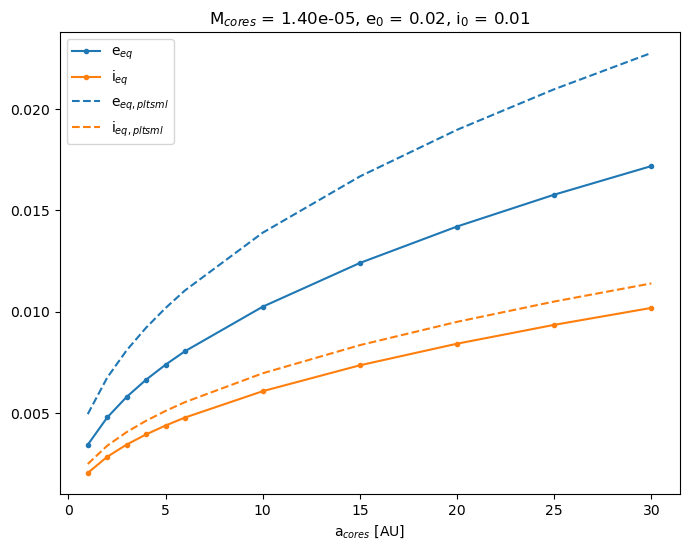

e_eq = [0.0034175340078332825, 0.0047640084358432444, 0.005781155277405044, 0.006629785359764492, 0.00737159414777645, 0.008038004394346066, 0.010238564216679449, 0.01240052385175038, 0.01420253438747442, 0.01577666211566372, 0.017190836451848913]
i_eq = [0.0020231313035195997, 0.0028209072738882056, 0.0034233791308201844, 0.00392597509904032, 0.004365277635506503, 0.004759912168638824, 0.006062966548395033, 0.007343100104894556, 0.008410074386163693, 0.009342105712374612, 0.010180022989370908]


In [21]:
## drag and VS_pltsml

drag = True
VS_embryo = False
VS_pltsml = True
DF = False

a_cores = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 10.0, 15.0, 20.0, 25.0, 30.0]) # AU
n_cores = len(a_cores)
M_cores = np.full(n_cores, M_pltsml(R_pltsml) * 10) # Earth masses
e_0 = 0.02
i_0 = e_0 / 2

e_eq_num = []
i_eq_num = []

e_eq_err = []
i_eq_err = []

for a_0 in a_cores:
    sol = least_squares(equilibrium, x0 = np.array([e_0 ** 2, i_0 ** 2]), args = (a_0, a_cores, M_cores, drag, VS_embryo, VS_pltsml, DF), bounds = ([0, 0], [np.inf, np.inf]), ftol = 1e-14, xtol = 1e-14, gtol = 1e-14)

    e2_eq_num, i2_eq_num = sol.x

    e_eq_num.append(float(np.sqrt(e2_eq_num)))
    i_eq_num.append(float(np.sqrt(i2_eq_num)))

    e_eq_err.append(abs(sol.fun[0]))
    i_eq_err.append(abs(sol.fun[1]))

    if sol.success != True:
        print(f'{a_0} AU Message: {sol.message}')

fig, ax = plt.subplots(figsize = (8, 6))

ax.plot(a_cores, e_eq_num, marker = '.', color = 'tab:blue', label = r'e$_{eq}$')
ax.plot(a_cores, i_eq_num, marker = '.', color = 'tab:orange', label = r'i$_{eq}$')

ax.plot(a_cores, [e_eq_VS_pltsml(a_0) for a_0 in a_cores], linestyle = '--', color = 'tab:blue', label = r'e$_{eq, pltsml}$')
ax.plot(a_cores, [i_eq(e_eq_VS_pltsml(a_0)) for a_0 in a_cores], linestyle = '--', color = 'tab:orange', label = r'i$_{eq, pltsml}$')

plt.xlabel(r'a$_{cores}$ [AU]')
plt.title(fr'M$_{{cores}}$ = {M_cores[0]:.2e}, e$_{{0}}$ = {e_0}, i$_{{0}}$ = {i_0}')
ax.legend()

plt.show()

print(f'e_eq = {e_eq_num}')
print(f'i_eq = {i_eq_num}')

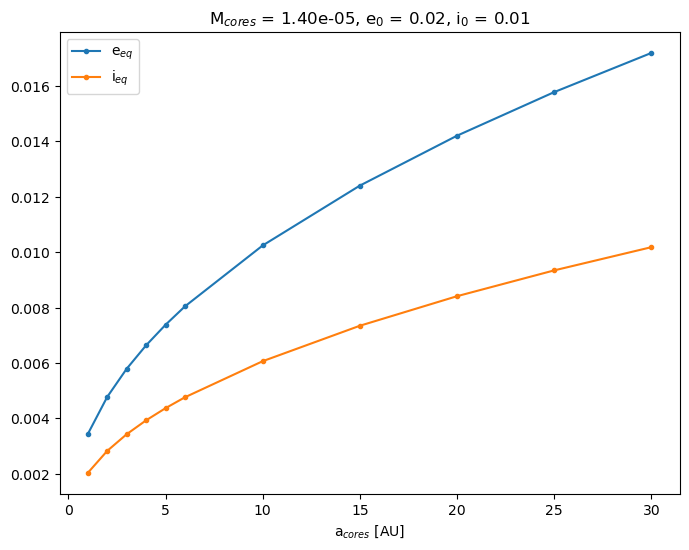

e_eq = [0.003434403874473749, 0.0047763097603279745, 0.005791489631845025, 0.006638972951459342, 0.007380009698558473, 0.00804583332698746, 0.010245130456306937, 0.0124064677679153, 0.014208235618466705, 0.0157822992178851, 0.017196489606767174]
i_eq = [0.0020327584462031326, 0.002828061921826308, 0.0034294292627045394, 0.00393137155904627, 0.004370230309262944, 0.004764525563257662, 0.006066845608962359, 0.007346615677748371, 0.008413448279155033, 0.009345442683054957, 0.010183363912879483]


In [22]:
## drag, VS_embryo, and VS_pltsml

drag = True
VS_embryo = True
VS_pltsml = True
DF = False

a_cores = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 10.0, 15.0, 20.0, 25.0, 30.0]) # AU
n_cores = len(a_cores)
M_cores = np.full(n_cores, M_pltsml(R_pltsml) * 10) # Earth masses
e_0 = 0.02
i_0 = e_0 / 2

e_eq_num = []
i_eq_num = []

e_eq_err = []
i_eq_err = []

for a_0 in a_cores:
    sol = least_squares(equilibrium, x0 = np.array([e_0 ** 2, i_0 ** 2]), args = (a_0, a_cores, M_cores, drag, VS_embryo, VS_pltsml, DF), bounds = ([0, 0], [np.inf, np.inf]), ftol = 1e-14, xtol = 1e-14, gtol = 1e-14)

    e2_eq_num, i2_eq_num = sol.x

    e_eq_num.append(float(np.sqrt(e2_eq_num)))
    i_eq_num.append(float(np.sqrt(i2_eq_num)))

    e_eq_err.append(abs(sol.fun[0]))
    i_eq_err.append(abs(sol.fun[1]))

    if sol.success != True:
        print(f'{a_0} AU Message: {sol.message}')

fig, ax = plt.subplots(figsize = (8, 6))

ax.plot(a_cores, e_eq_num, marker = '.', color = 'tab:blue', label = r'e$_{eq}$')
ax.plot(a_cores, i_eq_num, marker = '.', color = 'tab:orange', label = r'i$_{eq}$')

plt.xlabel(r'a$_{cores}$ [AU]')
plt.title(fr'M$_{{cores}}$ = {M_cores[0]:.2e}, e$_{{0}}$ = {e_0}, i$_{{0}}$ = {i_0}')
ax.legend()

plt.show()

print(f'e_eq = {e_eq_num}')
print(f'i_eq = {i_eq_num}')